In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ==========================================
# ZONE 1: DATA MANAGEMENT
# ==========================================
def load_and_filter_data(filepath, target_activity):
    """Loads the pickle file and filters down strictly to the target activity."""
    print(f" Loading data from: {filepath} ...")
    df = pd.read_pickle(filepath)

    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')

    print(f" Pre-filter shape: {df.shape}")
    # Filter for single activity (e.g., 'walk')
    df = df[df['Activity'] == target_activity].copy()
    df.reset_index(drop=True, inplace=True)
    print(f" Post-filter shape (Only '{target_activity}'): {df.shape}")

    return df

# ==========================================
# ZONE 2: REGRESSION PIPELINE (ANN)
# ==========================================
class BiosignalRegressor:
    def __init__(self, window_size=200, overlap=100):
        self.window_size = window_size
        self.overlap = overlap
        self.step_size = window_size - overlap
        
        self.scaler = StandardScaler()
        self.ann_model = MLPRegressor(
            hidden_layer_sizes=(30,), #30,
            activation='relu', #tanh\relu
            solver='adam',
            max_iter=500,
            early_stopping=True,
            random_state=42
        )

    def segment_and_extract(self, df):
        """
        Slides a window across the dataframe to create our Inputs (X) and Targets (y).
        
        INPUTS (X): EMG muscle features and IMU kinematics.
        TARGETS (y): The 6 actual joint angles recorded by the Goniometers.
        """
        print(" Segmenting signals and calculating features...")
        
        emg_cols = [c for c in df.columns if 'EMG_TA_xx' in c or 'EMG_GM_xx' in c]
        imu_cols = [c for c in df.columns if c.endswith('-f') or c.endswith('-c') or c.endswith('-q') or c.endswith('-h')]
        gonio_cols = [c for c in df.columns if c.startswith('G_')]
        
        X_features, y_targets = [], []
        
        emg_data = df[emg_cols].to_numpy(dtype=np.float32)
        imu_data = df[imu_cols].to_numpy(dtype=np.float32)
        gonio_data = df[gonio_cols].to_numpy(dtype=np.float32)
        
        for start_idx in range(0, len(df) - self.window_size, self.step_size):
            end_idx = start_idx + self.window_size
            window_features = []
            
            # --- INPUTS (X): EMG & IMU ---
            w_emg = emg_data[start_idx:end_idx]
            
            # 1. RMS
            window_features.extend(np.sqrt(np.mean(w_emg**2, axis=0)))
            # 2. MAV
            window_features.extend(np.mean(np.abs(w_emg), axis=0))
            # 3. Waveform Length (WL)
            window_features.extend(np.sum(np.abs(np.diff(w_emg, axis=0)), axis=0))
            # 4. Zero Crossings (ZC)
            window_features.extend(np.sum((w_emg[:-1] * w_emg[1:]) < 0, axis=0))
            # 5. Slope Sign Changes (SSC) 
            diffs = np.diff(w_emg, axis=0)
            ssc = np.sum((diffs[:-1] * diffs[1:]) < 0, axis=0)
            window_features.extend(ssc)
            
            # IMU Features (Mean & RMS)
            w_imu = imu_data[start_idx:end_idx]
            window_features.extend(np.mean(w_imu, axis=0))
            window_features.extend(np.sqrt(np.mean(w_imu**2, axis=0)))
            
            X_features.append(window_features)
            
            # --- TARGETS (y): Goniometer Angles ---
            # Using the mean angle of the window as the target value
            w_gonio = gonio_data[start_idx:end_idx]
            y_targets.append(np.mean(w_gonio, axis=0))
            
        return np.nan_to_num(np.array(X_features)), np.array(y_targets)

    def train_model(self, X_train, y_train):
        X_train_scaled = self.scaler.fit_transform(X_train)
        self.ann_model.fit(X_train_scaled, y_train)
        return self.ann_model, self.scaler

# ==========================================
# ZONE 3: POST-PROCESSING & VISUALIZATION
# ==========================================
def smooth_predictions(predictions, window=10):
    """Replicates the MATLAB Moving Average (MA) filter using Pandas rolling mean."""
    df_preds = pd.DataFrame(predictions)
    # Applying a centered moving average
    smoothed = df_preds.rolling(window=window, center=True, min_periods=1).mean()
    return smoothed.to_numpy()

def plot_kinematics(y_true, y_pred_smoothed, channel_idx=0, title="Actual vs Estimated Kinematics"):
    """Plots the continuous estimated angle vs the actual cue."""
    plt.figure(figsize=(12, 5))
    # Extracting a specific slice (e.g., first 500 windows) for visual clarity
    plt.plot(y_true[:20, channel_idx], label='Actual Goniometer (CUE)', color='blue', linewidth=2)
    plt.plot(y_pred_smoothed[:20, channel_idx], label='Estimated (ANN)', color='orange', linestyle='dashed', linewidth=2)
    
    plt.title(title)
    plt.xlabel('Time (Windows)')
    plt.ylabel('Angle (Degrees)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [2]:

# MAIN EXECUTION CONTROLLER
BASE_PATH = "/Users/li0o0sun/projects/Projectwork2026/data"
FILE_NAME = "09_filtered_all_data.pkl"

# 1. Load strictly "walk" data
df = load_and_filter_data(os.path.join(BASE_PATH, FILE_NAME), target_activity='walk')


 Loading data from: /Users/li0o0sun/projects/Projectwork2026/data/09_filtered_all_data.pkl ...
 Pre-filter shape: (1488351, 162)
 Post-filter shape (Only 'walk'): (365925, 162)


In [3]:
 
# 2. Segment and Extract
regressor_pipeline = BiosignalRegressor(window_size=200, overlap=100)
X, y = regressor_pipeline.segment_and_extract(df)
print(f" Extracted X shape: {X.shape}, y shape: {y.shape}")

# 3. Train/Test Split (Sequential split to preserve time-series nature)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 4. Train ANN
print(" Training ANN Regressor...")
model, scaler = regressor_pipeline.train_model(X_train, y_train)
print(" Training completed!")

# 5. Predict 
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

# y_pred = smooth_predictions(y_pred, window=3)
        

 Segmenting signals and calculating features...
 Extracted X shape: (3658, 48), y shape: (3658, 6)
 Training ANN Regressor...
 Training completed!


/opt/miniconda3/envs/hte/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



 Regression Performance:
G_DA_X (Dominant Ankle - Sagittal)
  RMSE: 0.60 degrees | R²: 0.8013 | MAE: 0.4747 degrees

G_DA_Y (Dominant Ankle - Frontal)
  RMSE: 1.55 degrees | R²: 0.8428 | MAE: 1.0458 degrees

G_DK_X (Dominant Knee - Sagittal)
  RMSE: 4.44 degrees | R²: 0.9482 | MAE: 3.4345 degrees

G_DK_Y (Dominant Knee - Frontal)
  RMSE: 0.90 degrees | R²: 0.9171 | MAE: 0.6844 degrees

G_NDA_X (Non-Dominant Ankle - Sagittal)
  RMSE: 0.66 degrees | R²: 0.8251 | MAE: 0.5514 degrees

G_NDA_Y (Non-Dominant Ankle - Frontal)
  RMSE: 0.01 degrees | R²: -818.7928 | MAE: 0.0096 degrees



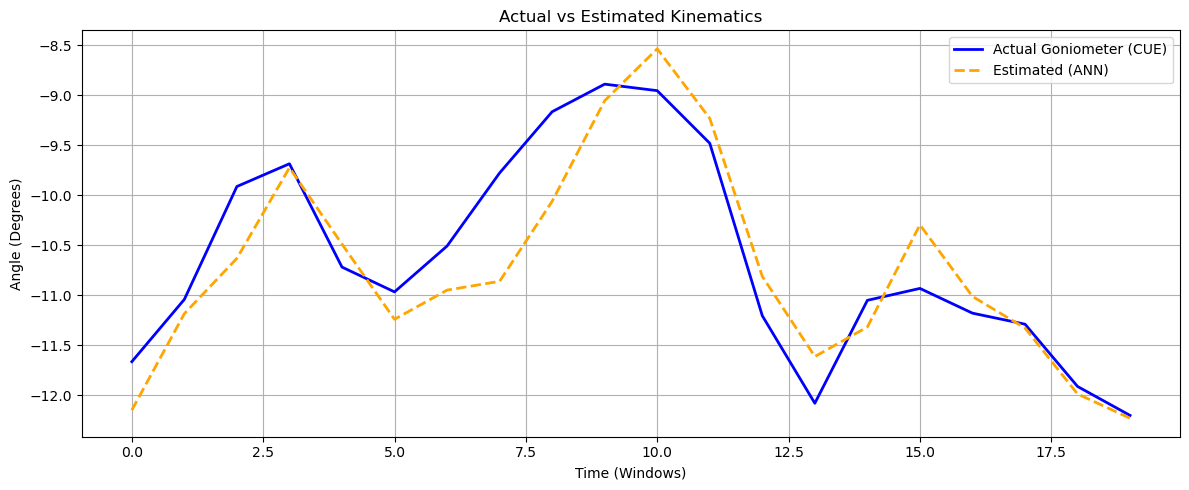

In [4]:
# 6. Calculate Performance Metrics
print("\n Regression Performance:")

# Axis names
axis_names = [
    "G_DA_X (Dominant Ankle - Sagittal)",
    "G_DA_Y (Dominant Ankle - Frontal)",
    "G_DK_X (Dominant Knee - Sagittal)",
    "G_DK_Y (Dominant Knee - Frontal)",
    "G_NDA_X (Non-Dominant Ankle - Sagittal)",
    "G_NDA_Y (Non-Dominant Ankle - Frontal)"
]

# Loop through all axes
for idx in range(y_test.shape[1]):
    rmse = np.sqrt(mean_squared_error(y_test[:, idx], y_pred[:, idx]))
    r2 = r2_score(y_test[:, idx], y_pred[:, idx])
    mae_value = mean_absolute_error(y_test[:, idx], y_pred[:, idx])
    
    print(f"{axis_names[idx]}")
    print(f"  RMSE: {rmse:.2f} degrees | R²: {r2:.4f} | MAE: {mae_value:.4f} degrees\n")
    
# 7. Visualize
idx = 0;
plot_kinematics(y_test, y_pred, channel_idx=idx)

In [5]:
def export_mlp_to_c(scaler, mlp_model, output_file="model_regressor.h"):
    """
    Extracts the Scaler and MLPRegressor weights into a C-compatible header file.
    """
    print(f"\n Generating C header for MLP Regressor: {output_file}...")
    
    # 1. Extract Scaler variables
    mean = scaler.mean_
    scale = scaler.scale_
    
    # 2. Extract MLP weights and biases
    # mlp.coefs_[0] is W1 shape (n_features, n_hidden)
    # mlp.intercepts_[0] is b1 shape (n_hidden,)
    W1 = mlp_model.coefs_[0]
    b1 = mlp_model.intercepts_[0]
    
    # mlp.coefs_[1] is W2 shape (n_hidden, n_targets)
    # mlp.intercepts_[1] is b2 shape (n_targets,)
    W2 = mlp_model.coefs_[1]
    b2 = mlp_model.intercepts_[1]
    
    n_features = W1.shape[0]
    n_hidden = W1.shape[1]
    n_targets = W2.shape[1]

    with open(output_file, 'w') as f:
        f.write("/* Auto-generated MLP Neural Network Parameters */\n")
        f.write("#ifndef MODEL_REGRESSOR_H\n#define MODEL_REGRESSOR_H\n\n")
        
        f.write(f"#define NUM_FEATURES {n_features}\n")
        f.write(f"#define NUM_HIDDEN {n_hidden}\n")
        f.write(f"#define NUM_TARGETS {n_targets}\n\n")

        # --- SCALER ---
        f.write("const float scaler_mean[NUM_FEATURES] = {\n    " + ", ".join([f"{x:.6f}f" for x in mean]) + "\n};\n\n")
        f.write("const float scaler_scale[NUM_FEATURES] = {\n    " + ", ".join([f"{x:.6f}f" for x in scale]) + "\n};\n\n")
        
        # --- HIDDEN LAYER (W1 and B1) ---
        # Transpose W1 so it's shape (n_hidden, n_features) for C array mapping
        W1_T = W1.T
        f.write("const float W1[NUM_HIDDEN][NUM_FEATURES] = {\n")
        for i in range(n_hidden):
            row_str = ", ".join([f"{x:.6f}f" for x in W1_T[i]])
            f.write(f"    {{{row_str}}}")
            f.write(",\n" if i < n_hidden - 1 else "\n")
        f.write("};\n\n")
        
        f.write("const float b1[NUM_HIDDEN] = {\n    " + ", ".join([f"{x:.6f}f" for x in b1]) + "\n};\n\n")

        # --- OUTPUT LAYER (W2 and B2) ---
        # Transpose W2 so it's shape (n_targets, n_hidden)
        W2_T = W2.T
        f.write("const float W2[NUM_TARGETS][NUM_HIDDEN] = {\n")
        for i in range(n_targets):
            row_str = ", ".join([f"{x:.6f}f" for x in W2_T[i]])
            f.write(f"    {{{row_str}}}")
            f.write(",\n" if i < n_targets - 1 else "\n")
        f.write("};\n\n")
        
        f.write("const float b2[NUM_TARGETS] = {\n    " + ", ".join([f"{x:.6f}f" for x in b2]) + "\n};\n\n")
        
        f.write("#endif // MODEL_REGRESSOR_H\n")
        
    print(f"Successfully generated {output_file}!")

In [6]:
def export_regressor_test_data_to_c(X_test, y_test, num_samples=100, output_file="test_data_reg.h"):
    """Exports a sequential subset of features and continuous targets to a 2D C array."""
    print(f"\n Extracting {num_samples} sequential test samples to {output_file}...")
    
    X_subset = np.array(X_test[:num_samples], dtype=np.float32)
    
    # Ensure y_subset is explicitly 2D (e.g., N x 1 or N x 6)
    y_subset = np.array(y_test[:num_samples], dtype=np.float32)
    if len(y_subset.shape) == 1:
        y_subset = y_subset.reshape(-1, 1) # Force 2D if it ever accidentally becomes 1D

    n_samples = X_subset.shape[0]
    n_features = X_subset.shape[1]
    n_targets = y_subset.shape[1]

    with open(output_file, 'w') as f:
        f.write("/* Auto-generated Continuous Test Dataset for Regressor */\n")
        f.write("#ifndef TEST_DATA_REG_H\n#define TEST_DATA_REG_H\n\n")
        f.write(f"#define NUM_TEST_SAMPLES {n_samples}\n")
        f.write(f"#define NUM_TEST_FEATURES {n_features}\n")
        f.write(f"#define NUM_TEST_TARGETS {n_targets}\n\n")

        # --- FEATURES ARRAY ---
        f.write("const float test_features[NUM_TEST_SAMPLES][NUM_TEST_FEATURES] = {\n")
        for i in range(n_samples):
            row_str = ", ".join([f"{val:.6f}f" for val in X_subset[i]])
            f.write(f"    {{{row_str}}}")
            f.write(",\n" if i < n_samples - 1 else "\n")
        f.write("};\n\n")

        # --- TARGETS ARRAY (Joint Angles) ---
        f.write("const float test_targets[NUM_TEST_SAMPLES][NUM_TEST_TARGETS] = {\n")
        for i in range(n_samples):
            row_str = ", ".join([f"{val:.6f}f" for val in y_subset[i]])
            f.write(f"    {{{row_str}}}")
            f.write(",\n" if i < n_samples - 1 else "\n")
        f.write("};\n\n")

        f.write("#endif // TEST_DATA_REG_H\n")
        
    print(" Regressor test data export complete!")

In [7]:
# 8. Export to C Header (Regressor & Test Data)

MODELS_DIR = "/Users/li0o0sun/projects/Projectwork2026/models"
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Export the Model Weights (ANN)
output_model_file = os.path.join(MODELS_DIR, "model_regressor.h")
export_mlp_to_c(scaler, model, output_model_file)

# 2. Export 100 Sequential Test Samples
# We DO NOT shuffle here, so the embedded device can simulate a smooth 10-second walk!
output_test_file = os.path.join(MODELS_DIR, "test_data_reg.h")
export_regressor_test_data_to_c(X_test, y_test, num_samples=100, output_file=output_test_file)


 Generating C header for MLP Regressor: /Users/li0o0sun/projects/Projectwork2026/models/model_regressor.h...
Successfully generated /Users/li0o0sun/projects/Projectwork2026/models/model_regressor.h!

 Extracting 100 sequential test samples to /Users/li0o0sun/projects/Projectwork2026/models/test_data_reg.h...
 Regressor test data export complete!
